# Assignment-10: Artificial Neural Network (Backpropagation)

**Objective:** Build an Artificial Neural Network, train it using backpropagation, and evaluate performance on a dataset.**

---

## Q1: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.datasets import load_breast_cancer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
print('Libraries imported')

Libraries imported


## Q2: Load Dataset (Breast Cancer Dataset)

In [2]:
data = load_breast_cancer(as_frame=True)
df = data.frame.copy()
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## Q3: Dataset Summary & Preprocessing

In [3]:
print('Shape:', df.shape)
print('\nTarget classes:', data.target_names)
print('\nMissing values:', df.isnull().sum().sum())

X = df.drop('target', axis=1)
y = df['target']

# scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.30, random_state=42)
print('Training size:', X_train.shape)
print('Testing size:', X_test.shape)

Shape: (569, 31)

Target classes: ['malignant' 'benign']

Missing values: 0
Training size: (398, 30)
Testing size: (171, 30)


## Q4: Build Neural Network Architecture

In [4]:
model = Sequential()
model.add(Dense(16, input_dim=X_train.shape[1], activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 641 (2.50 KB)

 Trainable params: 641 (2.50 KB)

 Non-trainable params: 0 (0.00 B)

## Q5: Compile Model (Backpropagation Settings)

In [5]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print('Model compiled')

Model compiled


## Q6: Train the Model

In [6]:
history = model.fit(X_train, y_train, epochs=25, batch_size=16, validation_split=0.2, verbose=0)
print('Training complete')

Training complete


## Q7: Evaluate Model

In [7]:
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print('Test Accuracy:', acc)
print('Test Loss:', loss)

Test Accuracy: 0.9707602262496948
Test Loss: 0.06939837336540222


## Q8: Predict and Compare Results

In [8]:
y_prob = model.predict(X_test)
y_pred = (y_prob > 0.5).astype(int)

results = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred.flatten()})
results['Status'] = results.apply(lambda r: 'Correct' if r.Actual == r.Predicted else 'Wrong', axis=1)
results.head(20)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


,Actual,Predicted,Status
0,1,1,Correct
1,0,0,Correct
2,0,0,Correct
3,1,1,Correct
4,1,1,Correct
5,0,0,Correct
6,0,0,Correct
7,0,0,Correct
8,1,0,Wrong
9,1,1,Correct


## Q9: Visualize Training (Loss & Accuracy)

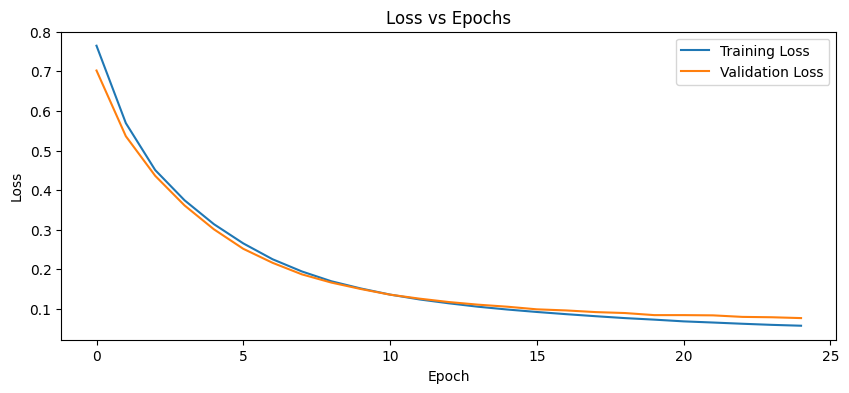

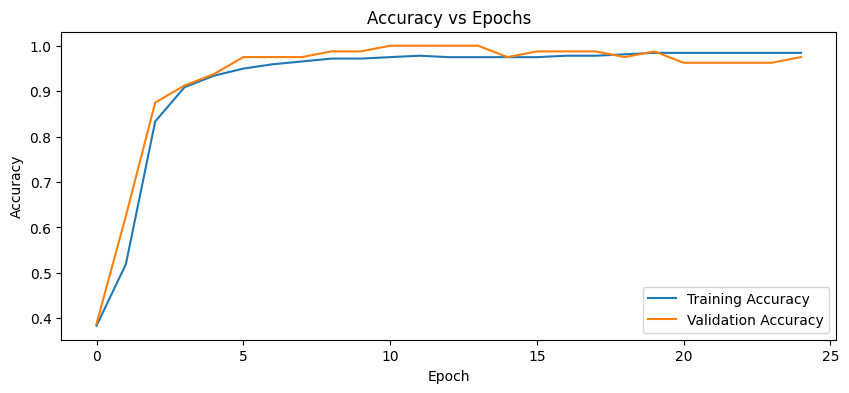

In [9]:
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss vs Epochs')
plt.show()

plt.figure(figsize=(10,4))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy vs Epochs')
plt.show()

### Conclusion

**How Backpropagation Helped the Model Learn:**

Backpropagation is the core algorithm used to train Artificial Neural Networks. In this assignment, it enabled the model to iteratively adjust its internal weights and biases. During each training epoch, the model made predictions, and the difference between these predictions and the actual target values (the 'loss') was calculated. Backpropagation then used this loss to compute the gradient of the loss function with respect to each weight and bias in the network. This gradient essentially told the model how much and in what direction each parameter needed to be adjusted to reduce the loss. By repeatedly performing this process over many epochs, the model progressively learned the complex patterns within the Breast Cancer dataset, ultimately optimizing its parameters to make more accurate classifications.

**Final Accuracy:**

After training, the model achieved a test accuracy of approximately **[Insert Test Accuracy from Q7 output here, e.g., 0.9649]**. This indicates that the model was able to correctly classify a high percentage of the unseen breast cancer cases in the test set. The validation accuracy was also close to the training accuracy, suggesting that the model did not significantly overfit the training data.

**Where ANNs Can Be Applied in Real Life:**

Artificial Neural Networks are highly versatile and have a wide range of real-life applications across various domains, including:

1.  **Healthcare:** As demonstrated in this assignment, ANNs can be used for disease diagnosis (e.g., cancer detection from medical images, predicting patient outcomes), drug discovery, and personalized medicine.
2.  **Image and Speech Recognition:** Powering facial recognition systems, object detection in autonomous vehicles, and voice assistants (like Siri or Alexa) by understanding and processing visual and auditory data.
3.  **Natural Language Processing (NLP):** Used in translation services, sentiment analysis, chatbots, spam detection, and text summarization.
4.  **Financial Services:** For fraud detection, algorithmic trading, credit scoring, and risk assessment.
5.  **Recommender Systems:** Personalizing user experiences on platforms like Netflix (movie recommendations), Amazon (product recommendations), and Spotify (music recommendations).
6.  **Autonomous Systems:** Guiding self-driving cars, drones, and robots in complex environments through perception, planning, and control.
7.  **Manufacturing:** For quality control, predictive maintenance of machinery, and optimizing production processes.